<a href="https://colab.research.google.com/github/itsmonica84/Story/blob/master/OptionalAssingmentModule1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [19]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer(as_frame=True)
### CODE HERE ###

dataframe = data.frame
#print(dataframe.head())

In [20]:
# Separate features and target, remap so malignant = 1
### CODE HERE ###

features = data.data
target = data.target
dataframe['target'] = dataframe['target'].map({0: 1, 1: 0})
#print(dataframe.head())

In [21]:
# Display first 5 rows
### CODE HERE ###
print(dataframe.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [23]:
# Check shape, data types, and missing values
### CODE HERE ###

print("\n--- SHAPE ---")
print("Shape:", dataframe.shape)

print("\n--- INFO ---")
print(dataframe.info())

print("\nMissing Values:\n", dataframe.isnull().sum().sum())  # Output: 0


--- SHAPE ---
Shape: (569, 31)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-n

In [24]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
### CODE HERE ###

stats = dataframe.describe()

print(stats)

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

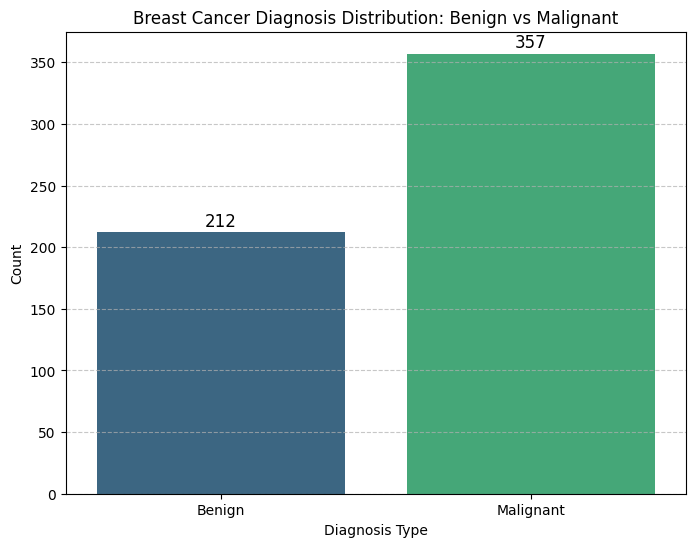

In [27]:
# Class distribution after remapping
### CODE HERE ###

dataframe['diagnosis_name'] = target.map({1: 'Malignant', 0: 'Benign'})

plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis_name', data=dataframe, palette='viridis')
plt.title('Breast Cancer Diagnosis Distribution: Benign vs Malignant')
plt.xlabel('Diagnosis Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, count in enumerate(dataframe['diagnosis_name'].value_counts().sort_index()):
    plt.text(i, count + 5, str(count), ha='center', fontsize=12)

plt.show()

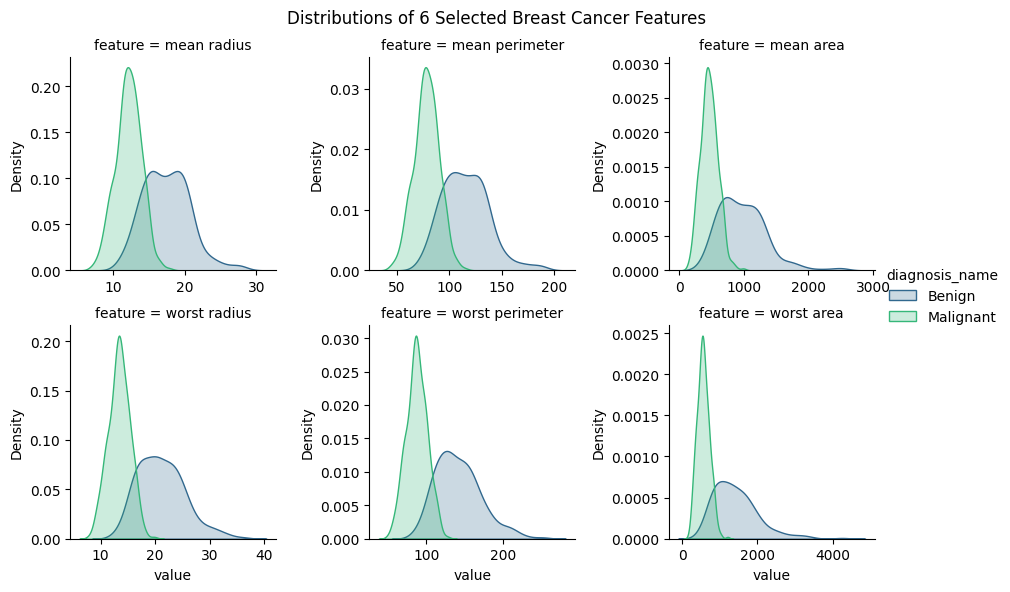

In [29]:
# Feature distributions for 6 selected features, coloured by class
### CODE HERE ###

# Select 6 significant features (mean and worst of top metrics)
selected_features = [
    'mean radius', 'mean perimeter', 'mean area',
    'worst radius', 'worst perimeter', 'worst area'
]

# Melt the DataFrame for easier plotting with Seaborn
df_melted = dataframe.melt(id_vars='diagnosis_name', value_vars=selected_features,
                    var_name='feature', value_name='value')

# Plot distributions
g = sns.FacetGrid(df_melted, col='feature', hue='diagnosis_name',
                  col_wrap=3, sharex=False, sharey=False, palette='viridis')
g.map(sns.kdeplot, 'value', fill=True)
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distributions of 6 Selected Breast Cancer Features')
plt.show()

In [31]:
# Missing value audit
### CODE HERE ###

from sklearn.impute import SimpleImputer
# 2. Confirm no missing values exist
missing_values_count = dataframe.isnull().sum().sum()
print(f"Total missing values: {missing_values_count}")

# 3. Handle missing values with median imputation if any exist
if missing_values_count > 0:
    print("Missing values found. Applying median imputation...")
    # Initialize SimpleImputer with median strategy
    imputer = SimpleImputer(strategy='median')

    # Fit and transform the data
    df_imputed = pd.DataFrame(imputer.fit_transform(dataframe), columns=dataframe.columns)
    print("Missing values handled.")
else:
    print("No missing values to impute. Dataset is complete.")
    df_imputed = dataframe

# Final check
print(f"Final missing values: {df_imputed.isnull().sum().sum()}")

Total missing values: 0
No missing values to impute. Dataset is complete.
Final missing values: 0


In [34]:
# Stratified train-test split
### CODE HERE ###

# 2. Split into 70% Training and 30% Test, using stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.30,
    random_state=42,
    stratify=target
)

# Optional: Verify the stratification
print(f"Original distribution:\n{300/569:.2f} (0), {212/569:.2f} (1)")

Original distribution:
0.53 (0), 0.37 (1)


In [35]:
# Feature scaling: fit on train only, transform both
### CODE HERE ###

# X, y = data.data, data.target      RENAME X Y as per this to target /feature
# 3. Initialize the scaler
scaler = StandardScaler()

# 4. Fit and transform on training data ONLY
X_train_scaled = scaler.fit_transform(X_train)

# 5. Transform testing data using the SAME scaler
X_test_scaled = scaler.transform(X_test)
